In [1]:
import torch
import pyvips as Vips
import numpy as np
import sys
sys.path.append("/home/mahirwar/Projects/LBD/LBD-Analysis/src/data")
from Reinhard import Reinhard
import cv2
from PIL import Image
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import geojson
import os
import cv2
from torch.utils.data import TensorDataset, DataLoader
from torchmetrics.classification import MulticlassConfusionMatrix
import pandas as pd
import time
from timeit import default_timer as timer
from threading import Thread
from concurrent.futures import ThreadPoolExecutor, wait, ALL_COMPLETED
import subprocess
import cupy as cp
from shapely.geometry import Polygon



def getVipsInfo(vips_img):
    # # Get bounds-x and bounds-y offeset
    vfields = [f.split('.') for f in vips_img.get_fields()]
    vfields = [f for f in vfields if f[0] == 'openslide']
    vfields = dict([('.'.join(k[1:]), vips_img.get('.'.join(k))) for k in vfields])
    return vfields

def load_saved_model(path):
    checkpoint = torch.load(path)
    model_ft = checkpoint["model"]
    model_ft.load_state_dict(checkpoint['state'])
    return model_ft

def crop2img(crop):
    crop_array = crop.numpy()
    crop_array = crop_array[:,:,:3]
    img = Image.fromarray(crop_array.astype('uint8'), 'RGB')
    return img

def normalization(REF_IMG_PATH):
    print("Init Normalization")
    ref_image = Vips.Image.new_from_file(REF_IMG_PATH)
    normalizer = Reinhard()
    normalizer.fit(ref_image)
    return normalizer


class TestDataset(torch.utils.data.Dataset):
    def __init__(self, img_list):
        super(TestDataset, self).__init__()
        self.img_list = img_list
        self.transforms = transforms.Compose([
        transforms.Resize(1024),
        transforms.ToTensor(),
        transforms.Normalize([-0.0601, -0.0667, -0.0616],[0.9118, 0.9479, 0.9625])
        #transforms.Normalize([0.8478, 0.8328, 0.8679], [0.0932, 0.0973, 0.0825])
        #transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
    def __len__(self):
        return len(self.img_list)
    
    def __getitem__(self, idx):
        img = self.img_list[idx]
        img = crop2img(img)
        transformed_img = self.transforms(img)
        transformed_img = torch.unsqueeze(transformed_img, dim=0)
        return transformed_img
    
def test(dataloader,device, model):
    model.eval()
    pred_labels = []
    with torch.no_grad():
        for X in dataloader:
            X= X.to(device).float()
            outputs = model(X)
            _, preds = torch.max(outputs, 1)
            pred_labels.extend(preds.tolist())
            #print(preds.tolist())
    return pred_labels


def get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,stride, tilesize):
    points = []
    stride = stride
    for x_val in range(x, x+downscaled_w-stride, stride): 
        for y_val in range(y, y + downscaled_h-stride, stride): 
            inside_1 = cv2.pointPolygonTest(cnt, (x_val, y_val), False)
            inside_2 = cv2.pointPolygonTest(cnt, (x_val+tilesize, y_val+tilesize), False)
            inside_3 = cv2.pointPolygonTest(cnt, (x_val, y_val+tilesize), False)
            inside_4 = cv2.pointPolygonTest(cnt, (x_val+tilesize, y_val), False)
            if (inside_1>= 0) and (inside_2>=0) and (inside_3>=0) and (inside_4>=0) : 
                points.append((x_val, y_val)) # points time scale factor print(f'Collected {len(self.points)} points') return self.points 
    return points

def crop_process(i, x, y, vips_orig_img, savesubdir, orig_w, orig_h):   
    print("Crop slide thread Started.", i) 
    savecroppath = os.path.join(savesubdir, f'{filename}_x_{x}_y_{y}.png')
    print(savecroppath)
    print((y + tilesize < orig_h) and (x + tilesize < orig_w))
    # row is y, col is x
    if y + tilesize < orig_h and x + tilesize < orig_w:
        # TODO change to vips cropping
        print("---------copying image---------")
        crop = vips_orig_img.crop(x, y, 1024, 1024)
        crop.write_to_file(savecroppath)
        print("Thread Stopped ", i)
        return 1
    else:
        print("Thread Stopped ", i)
        return 0


def tiling(cnt,vips_img, vips_array_copy, filename, class_type, orig_w, orig_h):
    cnt = cnt.astype(np.int)
    x,y,downscaled_w,downscaled_h = cv2.boundingRect(cnt)
    vips_array_copy = cv2.drawContours(vips_array_copy, [cnt],-1, (0,0,255),40)
    vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),30)
    points = get_points_in_contour(x,y,downscaled_w,downscaled_h,cnt,1024, 1024)
    print("count of points in contour:", len(points))
    for x, y in points:
        vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + tilesize,y + tilesize),color_codes[class_type],30)
    th = Image.fromarray(vips_array_copy)
    th.thumbnail((1000,1000))

    save_path = os.path.join(save_dir, filename)
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    th.save(os.path.join(save_path,filename.split(".")[0]+".png"))
    
    savesubdir = os.path.join(save_path, class_type)
    if not os.path.exists(savesubdir):
        os.makedirs(savesubdir)

    exe = ThreadPoolExecutor(max_workers=workers)
    futures = [exe.submit(crop_process, i, x_1, y_1, vips_img, savesubdir, orig_w, orig_h) for i, (x_1, y_1) in enumerate(points)]

    done, not_done = wait(futures, return_when=ALL_COMPLETED)
    exe.shutdown()
    print("done tiling")


tilesize = 1024
workers = 10
stride = 256
REF_IMG_PATH = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/11_063_CG_aSyn_x200.svs'
WM_model_path = '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/WM_models/3uctrn1o10.pth'
save_dir = "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD/Testing_results/wgm_model_crops1/"+WM_model_path.split("/")[-1]
color_codes =  {"White":(0,154,205), "grey":(255, 170, 51),"bg":(128,0,128)}
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
BATCH_SIZE =64

#def image_tiling(normalizer,img,model_wgm ):
imgs = ["/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/DLB_cases/04_028_Syn1_CG_200x.svs",
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/15_134_FCx_aSyn_x200.svs",
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/16_044_PCx_aSyn_x200.svs",
        #",
        '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/./DLB_cases/19_053_TCx_aSyn_x200.svs',
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD268_Syn1_CG.svs",
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD295_Syn1_FCx.svs",       
        '/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD125_Syn1_PCx.svs',
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD258_Syn1_PCx.svs",
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/PDD_cases/PDD_cases/PD110_Syn1_TCx.svs",
        "/gladstone/finkbeiner/steve/work/data/npsad_data/monika/LBD_Dataset/LBD/DLB_cases/14_133_FCx_aSyn_x200.svs"]

normalizer = normalization(REF_IMG_PATH)
model_wgm = load_saved_model(WM_model_path)

img =imgs[0]
print(img)
vips_img = Vips.Image.new_from_file(img, level=0)

#vips_img = Vips.Image.new_from_file(img, level=0)
vips_img = normalizer.transform(vips_img)
vinfo = getVipsInfo(vips_img)
orig_w, orig_h = int(vinfo['level[0].width']), int(vinfo['level[0].height'])
print(orig_w, orig_h)
vips_array=vips_img.numpy()
vips_array = vips_array[:,:,:3]
xy_coords = [(x_val,y_val) for x_val in range(0, orig_w-stride, stride) for y_val in range(0, orig_h-stride, stride) 
                if y_val + tilesize < orig_h and x_val + tilesize < orig_w]
crops = [vips_img.crop(z[0], z[1], tilesize, tilesize)  for z in xy_coords]

valDataset = TestDataset(crops)
valDataLoader = DataLoader(valDataset, batch_size=BATCH_SIZE, shuffle=False)
pred_labels =  test(valDataset,device, model_wgm)
masked_image = np.zeros((orig_h,orig_w))
for pred, z in zip(pred_labels,xy_coords):
    masked_image[z[1]:z[1]+tilesize, z[0]:z[0]+tilesize] = pred
    
grey_image=(masked_image==1).astype(int)
grey_image = np.array(grey_image,dtype=np.uint8)

#class_type = "grey"
#filename = img.split("/")[-1]
#vips_array_copy = vips_array.copy()
#tiling(c,vips_img, vips_array_copy, filename, class_type, orig_w, orig_h)  

Init Normalization


In [3]:

contours =  cv2.findContours(grey_image,cv2.RETR_TREE,cv2.CHAIN_APPROX_NONE)
print("count of contours: ", len(contours))
# Sort contours based on area
contours = sorted(contours[0], key=lambda x: cv2.contourArea(x), reverse=True)
# Extract the two contours with the maximum area
largest_contours = contours[:2]
#c = max(contours[0], key = cv2.contourArea)


count of contours:  2


In [11]:
area_list = sorted([cv2.contourArea(x) for x in contours[0]],reverse=True)
max(area_list)

0.0

In [5]:
# Create a polygon from contour points
#polygon = Polygon(c)
#x, y, w, h = cv2.boundingRect(cp.array(c).astype(cp.int32))

#x,y,downscaled_w,downscaled_h = cv2.boundingRect(cnt)
x,y,w,h = cv2.boundingRect(c)

# Crop the image using the bounding box#
cropped_image_gpu = image_gpu[y:y+h, x:x+w]


tiles = []
points = []
tile_size = 1024
for i in range(0, h, tile_size):
    for j in range(0, w, tile_size):
        #tile = cropped_image_gpu[i:i+tile_size, j:j+tile_size]
        # Check if the tile intersects with the contour polygon
        #tile_polygon = Polygon([(j, i), (j+tile_size, i), (j+tile_size, i+tile_size), (j, i+tile_size)])
        #if polygon.contains(tile_polygon):
        #    tiles.append(tile.get())
        inside_1 = cv2.pointPolygonTest(c, (i, j), False)
        inside_2 = cv2.pointPolygonTest(c, (i+tilesize, j+tilesize), False)
        inside_3 = cv2.pointPolygonTest(c, (i, j+tilesize), False)
        inside_4 = cv2.pointPolygonTest(c, (i+tilesize, j), False)
        if (inside_1>= 0) and (inside_2>=0) and (inside_3>=0) and (inside_4>=0) : 
            points.append((i, j)) # points time scale factor print(f'Collected {len(self.points)} points') return self.

In [7]:
len(points)

785

In [10]:
for x, y in points:
    vips_array_copy = cv2.rectangle(vips_array,(x, y),(x + tilesize,y + tilesize),color_codes["grey"],30)
th = Image.fromarray(vips_array_copy)
th.thumbnail((1000,1000))

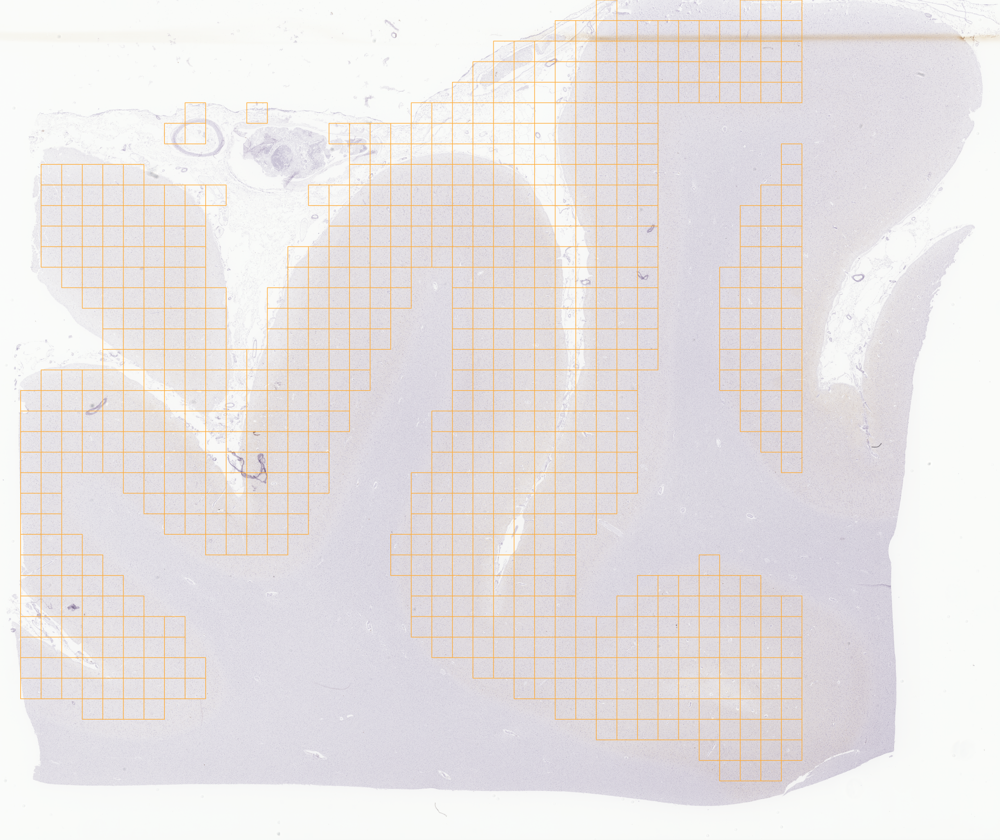

In [11]:
th

In [7]:
class_type = "grey"
vips_array_copy = vips_array.copy()
for c in largest_contours:
    x,y,downscaled_w,downscaled_h = cv2.boundingRect(c)
    vips_array_copy = cv2.drawContours(vips_array_copy, [c],-1, (0,0,255),40)
    vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + downscaled_w,y + downscaled_h),(0,255,0),30)
    points = get_points_in_contour(x,y,downscaled_w,downscaled_h,c,1024, 1024)
    print("count of points in contour:", len(points))
    for x, y in points:
        vips_array_copy = cv2.rectangle(vips_array_copy,(x, y),(x + tilesize,y + tilesize),color_codes[class_type],30)
th = Image.fromarray(vips_array_copy)
th.thumbnail((1000,1000))

count of points in contour: 430
count of points in contour: 16


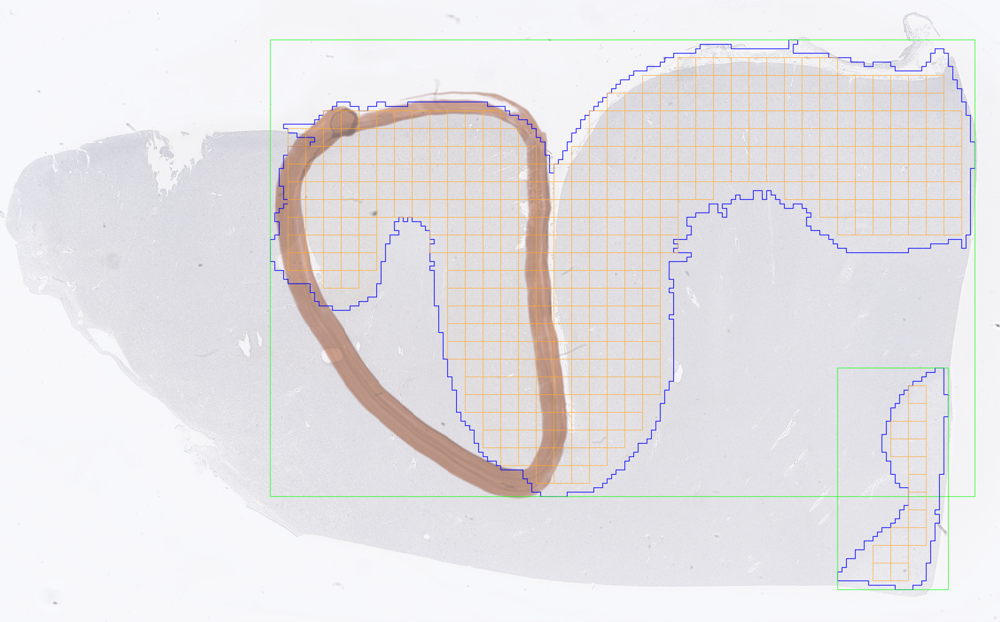

In [8]:
th